# 01 - CV Transformer Training and 
CV Extraction


In [1]:
# Requires: pip install -e .

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from graph_utils import calc_p_ratio_box
from course_project.config import ExperimentConfig
from course_project.runner import run_graph_cv_experiment
from course_project.data import load_dataset, resolve_dataset_splits
from course_project.graph import build_graph
from course_project.hessian import collect_cv_lambda5_points
from course_project.models import create_model, resolve_model_inputs


In [ ]:
import random
import shutil

force_train = True
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
print('run seed:', seed)

fixed_params = {
    'hidden_size': 128,
    'learning_rate': 5e-5,
}

time_lag_steps = 0
time_lag_weight = 0
CVs = 4
token_sizes = (120, 50, CVs)

dataset_mixture = [
    {
        'name': 'dePablo_undirected',
        'path': '../data/2340_dePablo_networks_OOL_undirected.pt',
        'train_count': 0,
    },
    {
        'name': 'aux_lowT_bidirect',
        'path': '../data/data_aux_opt_lowT_448sims_noang_bidirect.pt',
        'train_count': 20,
    },
]
train_count = sum(int(spec['train_count']) for spec in dataset_mixture)
val_count = 70
shuffle_dataset_within_source = True
split_seed = seed
mix_holdout_across_sources = True
full_dataset_path = 'mixed'

train_sims, val_sims, test_sims, split_info = resolve_dataset_splits(
    full_dataset_path,
    train_count=train_count,
    val_count=val_count,
    dataset_mixture=dataset_mixture,
    split_seed=split_seed,
    shuffle_within_source=shuffle_dataset_within_source,
    mix_holdout_across_sources=mix_holdout_across_sources,
)
split_info_df = pd.DataFrame(split_info)

print('dataset mixture:')
print(split_info_df.to_string(index=False))
print('train sims:', len(train_sims), 'val sims:', len(val_sims), 'test sims:', len(test_sims))

common_cfg = dict(
    dataset_path=full_dataset_path,
    dataset_mixture=dataset_mixture,
    split_seed=split_seed,
    shuffle_dataset_within_source=shuffle_dataset_within_source,
    mix_holdout_across_sources=mix_holdout_across_sources,
    train_count=train_count,
    val_count=val_count,
    output_root='../results',
    pos_dim=2,
    history=1,
    limit=20,
    n_layers=2,
    learning_rate_decay=0.997,
    weight_decay=0.0,
    epochs=12,
    val_every=2,
    rollout_every=0,
    cv_eval_every=2,
    freeze_normalizers_after_epoch=5,
    device='cuda',
)

cfg_cv_transformer = ExperimentConfig(
    run_name='cv_transformer_mixed_sources',
    model_type='cv_transformer',
    seed=seed,
    learning_rate=float(fixed_params['learning_rate']),
    hidden_size=int(fixed_params['hidden_size']),
    model_extras={
        'num_mlp': 3,
        'transformer_layers': 1,
        'transformer_heads': 1,
        'transformer_dropout': 0.001,
        'use_local_skip': True,
        'token_sizes': token_sizes,
        'time_lag_steps': int(time_lag_steps),
        'time_lag_weight': float(time_lag_weight),
    },
    **common_cfg,
)

run_dir = Path(cfg_cv_transformer.output_root) / cfg_cv_transformer.run_name
selection_json = Path(common_cfg['output_root']) / 'cv_transformer_best_cv_selection.json'
best_ckpt_out = Path(common_cfg['output_root']) / 'cv_transformer_best_cv_checkpoint.pt'

need_train = force_train or not (run_dir / 'train_stats.pt').exists() or not selection_json.exists() or not best_ckpt_out.exists()
if need_train:
    metrics = run_graph_cv_experiment(cfg_cv_transformer)
    stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)
    epochs = np.asarray(stats['epoch'], dtype=int)
    cv_fit_r2 = np.asarray(stats['cv_fit_r2'], dtype=float)
    best_idx = int(np.nanargmax(cv_fit_r2))
    best_epoch = int(epochs[best_idx])
    best_score = float(cv_fit_r2[best_idx])
    best_ckpt = run_dir / 'rollout_checkpoints' / f'epoch_{best_epoch:04d}.pt'
    shutil.copy2(best_ckpt, best_ckpt_out)
    selection = {
        'run_name': str(cfg_cv_transformer.run_name),
        'best_cv_fit_r2': best_score,
        'best_cv_epoch': best_epoch,
        'checkpoint_path': str(best_ckpt),
        'saved_checkpoint_path': str(best_ckpt_out),
        'fixed_params': fixed_params,
    }
    selection_json.write_text(json.dumps(selection, indent=2))
    print('single run:', cfg_cv_transformer.run_name)
    print('best cv_fit_r2:', best_score, 'epoch:', best_epoch)
    print('saved best checkpoint:', best_ckpt_out)
    print('saved selection:', selection_json)
else:
    print('using existing CV run from', run_dir)
    print('using existing selection from', selection_json)


run seed: 1595354462
dataset mixture:
            source                                                path  total  train  val  test
dePablo_undirected     ../data/2340_dePablo_networks_OOL_undirected.pt    100      0   37    63
 aux_lowT_bidirect ../data/data_aux_opt_lowT_448sims_noang_bidirect.pt    100     20   33    47
train sims: 20 val sims: 70 test sims: 110
[run] cv_transformer_mixed_sources model=cv_transformer device=cuda output=../results/cv_transformer_mixed_sources
[run] training...
[train] time-lag loss tau=0 lambda=0
[ep   2/12] tr=0.955 va=0.849 lr=4.97e-05 cv=cv_4 |p|=0.582 r2=0.339 (n=70) t=52.8s


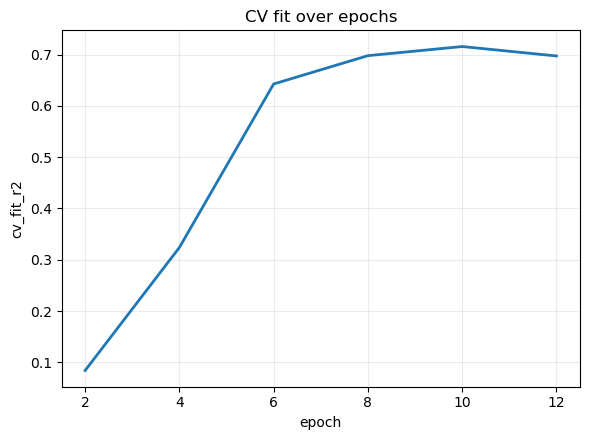

best cv_fit_r2= 0.7158368830759866 at epoch 10


In [ ]:
# CV-fit over epochs.
run_dir = Path(cfg_cv_transformer.output_root) / cfg_cv_transformer.run_name
stats = torch.load(run_dir / 'train_stats.pt', map_location='cpu', weights_only=False)

epochs = np.asarray(stats['epoch'], dtype=int)
cv_fit_r2 = np.asarray(stats['cv_fit_r2'], dtype=float)
mask_cv = np.isfinite(cv_fit_r2)

fig, ax = plt.subplots(figsize=(6.0, 4.5))
ax.plot(epochs[mask_cv], cv_fit_r2[mask_cv], '-', linewidth=2.0, color='tab:blue')
ax.set_xlabel('epoch')
ax.set_ylabel('cv_fit_r2')
ax.grid(alpha=0.25)
ax.set_title('CV fit over epochs')
plt.tight_layout()
plt.show()

best_i = int(np.nanargmax(cv_fit_r2))
print('best cv_fit_r2=', float(cv_fit_r2[best_i]), 'at epoch', int(epochs[best_i]))


In [ ]:
# Load model from the saved best CV-fit checkpoint.
output_root = Path(cfg_cv_transformer.output_root)
selection = json.loads((output_root / 'cv_transformer_best_cv_selection.json').read_text())

run_dir = output_root / selection['run_name']
cfg_dict = json.loads((run_dir / 'config.json').read_text())
cfg_dict.pop('split_info', None)
cfg_loaded = ExperimentConfig(**cfg_dict)

device = cfg_loaded.device

_train_data, val_data, test_data, split_info = resolve_dataset_splits(
    cfg_loaded.dataset_path,
    train_count=cfg_loaded.train_count,
    val_count=cfg_loaded.val_count,
    dataset_mixture=cfg_loaded.dataset_mixture,
    split_seed=cfg_loaded.split_seed,
    shuffle_within_source=cfg_loaded.shuffle_dataset_within_source,
    mix_holdout_across_sources=cfg_loaded.mix_holdout_across_sources,
)
split_info_df = pd.DataFrame(split_info)

init_frames = [val_data[0][i].to(device) for i in range(cfg_loaded.history + 1)]
init_graph = build_graph(input_graphs=init_frames).to(device)

model = create_model(
    model_type=cfg_loaded.model_type,
    init_graph=init_graph,
    pos_dim=cfg_loaded.pos_dim,
    hidden_size=cfg_loaded.hidden_size,
    n_layers=cfg_loaded.n_layers,
    extras=cfg_loaded.model_extras,
).to(device)

best_ckpt = Path(selection['saved_checkpoint_path'])
model.load_checkpoint(str(best_ckpt))

model.eval()
model.freeze_normalizers = True
for p in model.parameters():
    p.requires_grad = False
model_inputs_cls = resolve_model_inputs(cfg_loaded.model_type)

print('Loaded model:', cfg_loaded.model_type, 'device=', device)
print('Run dir:', run_dir)
print('Loaded best CV checkpoint:', best_ckpt)
print('best cv_fit_r2:', float(selection['best_cv_fit_r2']), 'epoch:', int(selection['best_cv_epoch']))
print('effective token sizes:', cfg_loaded.model_extras['token_sizes'])
print(split_info_df.to_string(index=False))
print('validation sims:', len(val_data), '| test sims:', len(test_data))


Loaded model: cv_transformer device= cuda
Run dir: ../results/cv_transformer_mixed_sources
Loaded best CV checkpoint: ../results/cv_transformer_best_cv_checkpoint.pt
best cv_fit_r2: 0.7158368830759866 epoch: 10
effective token sizes: [120, 50, 4]
            source                                                path  total  train  val  test
dePablo_undirected     ../data/2340_dePablo_networks_OOL_undirected.pt    100      5   30    65
 aux_lowT_bidirect ../data/data_aux_opt_lowT_448sims_noang_bidirect.pt    100     30   20    50
validation sims: 50 | test sims: 115


In [ ]:
# Extract trajectory-level CV summaries and final p-ratio for VAL and TEST.
def split_source_labels(cfg):
    if not cfg.dataset_mixture:
        val_labels = [Path(cfg.dataset_path).stem] * cfg.val_count
        test_count = len(load_dataset(cfg.dataset_path)) - cfg.train_count - cfg.val_count
        test_labels = [Path(cfg.dataset_path).stem] * max(0, test_count)
        return val_labels, test_labels

    generator = None
    if cfg.shuffle_dataset_within_source:
        generator = torch.Generator()
        generator.manual_seed(0 if cfg.split_seed is None else int(cfg.split_seed))

    pooled_holdout = []
    for source_idx, spec in enumerate(cfg.dataset_mixture):
        sims = load_dataset(spec['path'])
        if generator is not None:
            order = torch.randperm(len(sims), generator=generator).tolist()
            sims = [sims[i] for i in order]
        source_name = str(spec.get('name', f'source_{source_idx + 1}'))
        src_train = int(spec['train_count'])
        if cfg.mix_holdout_across_sources:
            pooled_holdout.extend([(source_name, sim) for sim in sims[src_train:]])
        else:
            src_val = int(spec['val_count'])
            pooled_holdout.extend([(source_name, sim) for sim in sims[src_train:src_train + src_val]])
            pooled_holdout.extend([(source_name, sim) for sim in sims[src_train + src_val:]])

    if cfg.mix_holdout_across_sources and generator is not None:
        order = torch.randperm(len(pooled_holdout), generator=generator).tolist()
        pooled_holdout = [pooled_holdout[i] for i in order]

    val_labels = [source for source, _ in pooled_holdout[:cfg.val_count]]
    test_labels = [source for source, _ in pooled_holdout[cfg.val_count:]]
    return val_labels, test_labels


cv_summary_type = 'mean'  # or 'median'


def extract_cv_summary(sims, split_name, source_labels):
    rows = []
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            n_local = len(sim) - 1
            final_pr = float(calc_p_ratio_box(sim, -1))
            cv_values = []
            for t in range(cfg_loaded.history, n_local):
                frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
                if t > 0:
                    prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                    cur_pos = frames[-1].to(device).x[:, : cfg_loaded.pos_dim]
                    frames[-1].vel_state = cur_pos - prev_pos
                input_graph = build_graph(frames).to(device)
                cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
                cv_values.append(np.asarray(cv, dtype=float).reshape(-1))

            cv_array = np.stack(cv_values, axis=0)
            cv_mean = np.mean(cv_array, axis=0)
            cv_median = np.median(cv_array, axis=0)
            row = {
                'split': split_name,
                'source': source_labels[sim_idx] if sim_idx < len(source_labels) else 'unknown',
                'sim_idx': sim_idx,
                'num_frames_used': len(cv_values),
                'final_p_ratio': final_pr,
            }
            for i, value in enumerate(cv_mean, start=1):
                row[f'cv_mean_{i}'] = float(value)
            for i, value in enumerate(cv_median, start=1):
                row[f'cv_median_{i}'] = float(value)
            rows.append(row)
    return pd.DataFrame(rows).sort_values('sim_idx').reset_index(drop=True)


def extract_cv_frames(sims, split_name):
    rows = []
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            n_local = len(sim) - 1
            for t in range(cfg_loaded.history, n_local):
                frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
                if t > 0:
                    prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                    cur_pos = frames[-1].to(device).x[:, : cfg_loaded.pos_dim]
                    frames[-1].vel_state = cur_pos - prev_pos
                input_graph = build_graph(frames).to(device)
                cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
                row = {'split': split_name, 'sim_idx': sim_idx, 't': int(t)}
                for i, value in enumerate(np.asarray(cv, dtype=float).reshape(-1), start=1):
                    row[f'cv_{i}'] = float(value)
                rows.append(row)
    return pd.DataFrame(rows)


def fit_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    coeff = np.polyfit(x, y, deg=1)
    y_hat = coeff[0] * x + coeff[1]
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    return float(1.0 - ss_res / ss_tot)


def cv_pratio_table(df, split_name, summary_type):
    rows = []
    prefix = f'cv_{summary_type}_'
    cv_cols = [c for c in df.columns if c.startswith(prefix)]
    y = df['final_p_ratio'].to_numpy(dtype=float)
    for col in cv_cols:
        x = df[col].to_numpy(dtype=float)
        rows.append({
            'split': split_name,
            'cv': col,
            'summary_type': summary_type,
            'pearson_r': float(np.corrcoef(x, y)[0, 1]),
            'spearman_r': float(df[col].corr(df['final_p_ratio'], method='spearman')),
            'fit_r2': fit_r2(x, y),
        })
    out = pd.DataFrame(rows)
    out['abs_pearson_r'] = out['pearson_r'].abs()
    return out.sort_values('abs_pearson_r', ascending=False).reset_index(drop=True)


val_source_labels, test_source_labels = split_source_labels(cfg_loaded)
df_val = extract_cv_summary(val_data, 'val', val_source_labels)
df_test = extract_cv_summary(test_data, 'test', test_source_labels)

val_cv_table = cv_pratio_table(df_val, 'val', cv_summary_type)
test_cv_table = cv_pratio_table(df_test, 'test', cv_summary_type)

cv_prefix = f'cv_{cv_summary_type}_'
cv_cols = [c for c in df_val.columns if c.startswith(cv_prefix)]
selected_cv_col = str(val_cv_table.iloc[0]['cv'])
selected_cv_idx = int(selected_cv_col.split('_')[-1]) - 1

print('CV summary type:', cv_summary_type)
print('selected CV for plots:', selected_cv_col, '(index:', selected_cv_idx, ')')
print(val_cv_table[['summary_type', 'cv', 'pearson_r', 'spearman_r', 'fit_r2']])


CV summary type: mean
selected CV for plots: cv_mean_3 (index: 2 )
  summary_type         cv  pearson_r  spearman_r    fit_r2
0         mean  cv_mean_3  -0.846071   -0.836735  0.715837
1         mean  cv_mean_1   0.840242    0.828667  0.706006
2         mean  cv_mean_2   0.819770    0.814262  0.672024
3         mean  cv_mean_4   0.174589    0.137287  0.030481


using CV pair: cv_1 and cv_4 | validation |r|= 0.034543757637816586


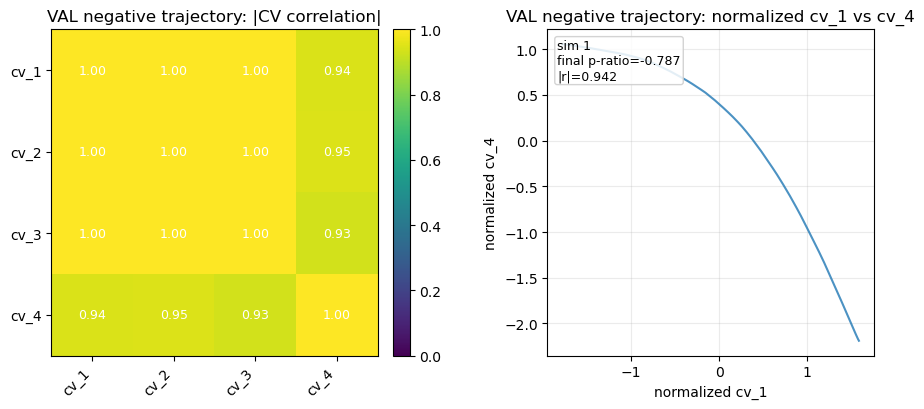

saved: ../results/cv_transformer_mixed_sources/cv_transformer_val_single_negative_cv_view.png


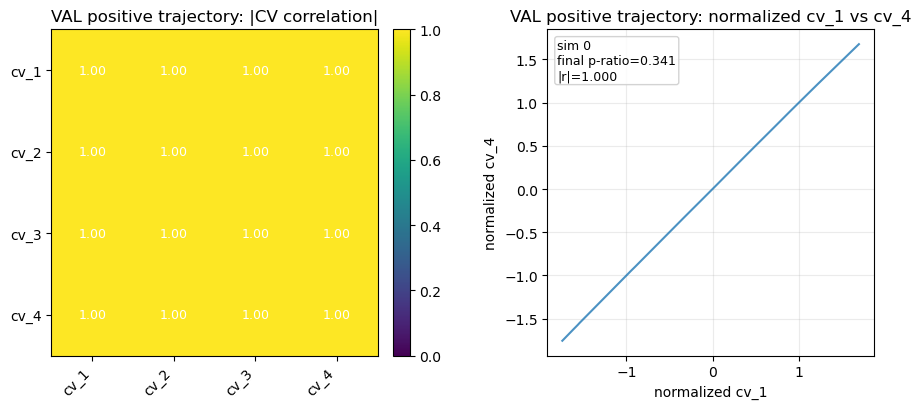

saved: ../results/cv_transformer_mixed_sources/cv_transformer_val_single_positive_cv_view.png


In [ ]:
# Single-trajectory VAL CV view: one negative and one positive final p-ratio trajectory.
frame_rows = []
with torch.no_grad():
    for sim_idx, sim in enumerate(val_data):
        for t in range(cfg_loaded.history, len(sim) - 1):
            frames = [sim[i].to(device) for i in range(t - cfg_loaded.history, t + 1)]
            if t > 0:
                prev_pos = sim[t - 1].to(device).x[:, : cfg_loaded.pos_dim]
                cur_pos = frames[-1].x[:, : cfg_loaded.pos_dim]
                frames[-1].vel_state = cur_pos - prev_pos
            input_graph = build_graph(frames).to(device)
            cv = model.extract_cv(input_graph, is_training=False).squeeze(0).detach().cpu().numpy()
            row = {'sim_idx': sim_idx, 't': t}
            for i, value in enumerate(np.asarray(cv, dtype=float).reshape(-1)):
                row[f'cv_{i + 1}'] = float(value)
            frame_rows.append(row)

frame_cv_df = pd.DataFrame(frame_rows)
cv_cols = [c for c in frame_cv_df.columns if c.startswith('cv_')]
c1 = cv_cols[0]
val_corr = np.abs(frame_cv_df[cv_cols].corr(method='pearson').to_numpy(dtype=float))
c1_idx = cv_cols.index(c1)
other_idx = [i for i in range(len(cv_cols)) if i != c1_idx]
c2_idx = min(other_idx, key=lambda i: val_corr[c1_idx, i])
c2 = cv_cols[c2_idx]
print('using CV pair:', c1, 'and', c2, '| validation |r|=', float(val_corr[c1_idx, c2_idx]))

val_pr = df_val[['sim_idx', 'final_p_ratio']]
neg_sim_idx = int(val_pr.loc[val_pr['final_p_ratio'] < 0, 'sim_idx'].iloc[0])
pos_sim_idx = int(val_pr.loc[val_pr['final_p_ratio'] > 0, 'sim_idx'].iloc[0])

def normalize_pair(sub, xcol, ycol):
    x = sub[xcol].to_numpy(dtype=float)
    y = sub[ycol].to_numpy(dtype=float)
    x = (x - x.mean()) / (x.std() + 1e-8)
    y = (y - y.mean()) / (y.std() + 1e-8)
    return x, y

def plot_one_sim(sim_idx, out_name, panel_title):
    sub = frame_cv_df[frame_cv_df['sim_idx'] == int(sim_idx)].reset_index(drop=True)
    pr = float(val_pr.loc[val_pr['sim_idx'] == int(sim_idx), 'final_p_ratio'].iloc[0])
    corr = np.abs(sub[cv_cols].corr(method='pearson').to_numpy(dtype=float))
    r = abs(float(sub[c1].corr(sub[c2], method='pearson')))
    x, y = normalize_pair(sub, c1, c2)

    fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))
    im = axes[0].imshow(corr, vmin=0.0, vmax=1.0, cmap='viridis')
    axes[0].set_xticks(range(len(cv_cols)))
    axes[0].set_yticks(range(len(cv_cols)))
    axes[0].set_xticklabels(cv_cols, rotation=45, ha='right')
    axes[0].set_yticklabels(cv_cols)
    axes[0].set_title(f'{panel_title}: |CV correlation|')
    for i in range(len(cv_cols)):
        for j in range(len(cv_cols)):
            axes[0].text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=9, color='white' if corr[i, j] > 0.55 else 'black')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].plot(x, y, color='tab:blue', alpha=0.8, linewidth=1.5)
    axes[1].set_title(f'{panel_title}: normalized {c1} vs {c2}')
    axes[1].text(
        0.03, 0.97,
        f'sim {sim_idx}\nfinal p-ratio={pr:.3f}\n|r|={r:.3f}',
        transform=axes[1].transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='0.8'),
    )
    axes[1].set_xlabel(f'normalized {c1}')
    axes[1].set_ylabel(f'normalized {c2}')
    axes[1].grid(alpha=0.25)
    axes[1].set_box_aspect(1)

    fig.tight_layout()
    out_path = run_dir / out_name
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved:', out_path)

plot_one_sim(neg_sim_idx, 'cv_transformer_val_single_negative_cv_view.png', 'VAL negative trajectory')
plot_one_sim(pos_sim_idx, 'cv_transformer_val_single_positive_cv_view.png', 'VAL positive trajectory')


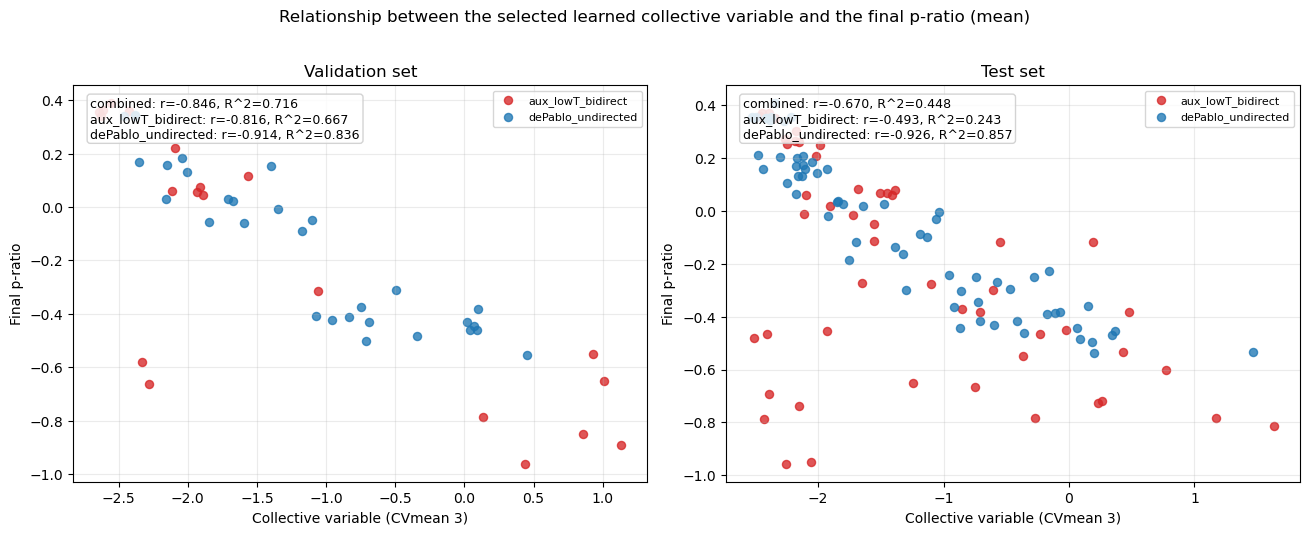

best checkpoint epoch: 10
saved: ../results/cv_transformer_mixed_sources/cv_transformer_val_selected_cv_vs_pratio.csv
saved: ../results/cv_transformer_mixed_sources/cv_transformer_test_selected_cv_vs_pratio.csv
saved: ../results/cv_transformer_mixed_sources/cv_transformer_test_all_cv_vs_pratio.csv
saved: ../results/cv_transformer_mixed_sources/cv_transformer_selected_cv_val_test_scatter.png


In [ ]:
# Report-style scatter of cv_2 (or fallback) against final p-ratio on VAL and TEST, colored by dataset source.
plot_cv_col = selected_cv_col
plot_cv_label = plot_cv_col.replace('cv_', 'CV').replace('_', ' ')
source_palette = {
    'dePablo_undirected': '#1f77b4',
    'aux_lowT_bidirect': '#d62728',
    'unknown': '#6b7280',
}


def scatter_panel(ax, df, title):
    x = df[plot_cv_col].to_numpy(dtype=float)
    y = df['final_p_ratio'].to_numpy(dtype=float)
    r = float(np.corrcoef(x, y)[0, 1])
    r2 = fit_r2(x, y)
    stat_lines = [f'combined: r={r:.3f}, R^2={r2:.3f}']
    for source_name, sub in df.groupby('source'):
        color = source_palette.get(source_name, '#6b7280')
        ax.scatter(sub[plot_cv_col], sub['final_p_ratio'], s=34, alpha=0.78, color=color, label=source_name)
        xs = sub[plot_cv_col].to_numpy(dtype=float)
        ys = sub['final_p_ratio'].to_numpy(dtype=float)
        if len(xs) >= 2 and not np.allclose(xs.std(), 0.0):
            source_r = float(np.corrcoef(xs, ys)[0, 1])
            source_r2 = fit_r2(xs, ys)
            stat_lines.append(f'{source_name}: r={source_r:.3f}, R^2={source_r2:.3f}')
        else:
            stat_lines.append(f'{source_name}: not enough spread')
    ax.set_title(title)
    ax.set_xlabel(f'Collective variable ({plot_cv_label})')
    ax.set_ylabel('Final p-ratio')
    ax.text(
        0.03, 0.97,
        '\n'.join(stat_lines),
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='0.8'),
    )
    ax.grid(alpha=0.25)
    ax.legend(loc='best', fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2))
scatter_panel(axes[0], df_val, 'Validation set')
scatter_panel(axes[1], df_test, 'Test set')

fig.suptitle(
    f'Relationship between the selected learned collective variable and the final p-ratio ({cv_summary_type})',
    y=1.02,
)
fig.tight_layout()

val_csv = run_dir / 'cv_transformer_val_selected_cv_vs_pratio.csv'
test_csv = run_dir / 'cv_transformer_test_selected_cv_vs_pratio.csv'
test_table_csv = run_dir / 'cv_transformer_test_all_cv_vs_pratio.csv'
plot_png = run_dir / 'cv_transformer_selected_cv_val_test_scatter.png'

df_val[['source', 'sim_idx', 'num_frames_used', plot_cv_col, 'final_p_ratio']].to_csv(val_csv, index=False)
df_test[['source', 'sim_idx', 'num_frames_used', plot_cv_col, 'final_p_ratio']].to_csv(test_csv, index=False)
test_cv_table.to_csv(test_table_csv, index=False)
fig.savefig(plot_png, dpi=180, bbox_inches='tight')

plt.show()

print('best checkpoint epoch:', int(selection['best_cv_epoch']))
print('saved:', val_csv)
print('saved:', test_csv)
print('saved:', test_table_csv)
print('saved:', plot_png)


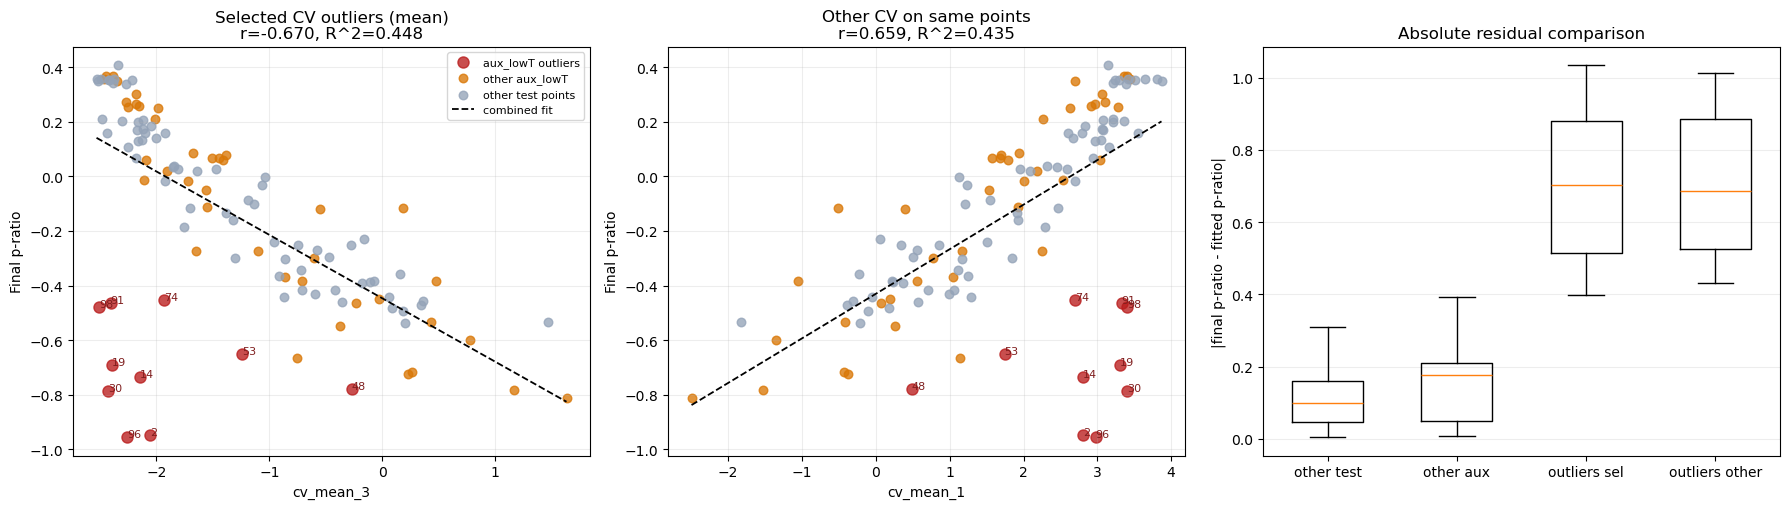

Top aux_lowT outliers on the test set


,source,sim_idx,num_frames_used,cv_mean_3,cv_mean_1,final_p_ratio,fit_pred_selected,fit_residual_selected,abs_fit_residual_selected,fit_pred_other,fit_residual_other,abs_fit_residual_other
0,aux_lowT_bidirect,96,423,-2.257278,2.976808,-0.956265,0.078236,-1.034501,1.034501,0.056315,-1.012580,1.012580
1,aux_lowT_bidirect,2,448,-2.053716,2.801674,-0.948545,0.030912,-0.979457,0.979457,0.027673,-0.976218,0.976218
2,aux_lowT_bidirect,30,507,-2.428776,3.404299,-0.786817,0.118107,-0.904923,0.904923,0.126228,-0.913045,0.913045
3,aux_lowT_bidirect,19,485,-2.395981,3.309776,-0.692503,0.110483,-0.802985,0.802985,0.110769,-0.803272,0.803272
4,aux_lowT_bidirect,14,386,-2.149234,2.801427,-0.737219,0.053118,-0.790338,0.790338,0.027633,-0.764852,0.764852
5,aux_lowT_bidirect,98,449,-2.510131,3.406770,-0.479298,0.137021,-0.616319,0.616319,0.126632,-0.605930,0.605930
6,aux_lowT_bidirect,91,471,-2.405548,3.328839,-0.464790,0.112707,-0.577497,0.577497,0.113887,-0.578677,0.578677
7,aux_lowT_bidirect,53,587,-1.243779,1.743230,-0.652407,-0.157385,-0.495023,0.495023,-0.145427,-0.506980,0.506980
8,aux_lowT_bidirect,74,622,-1.931240,2.701136,-0.453296,0.002438,-0.455734,0.455734,0.011231,-0.464527,0.464527
9,aux_lowT_bidirect,48,576,-0.268484,0.485984,-0.781491,-0.384124,-0.397367,0.397367,-0.351040,-0.430451,0.430451


Group summary


,group,n,selected_cv_mean,other_cv_mean,pr_mean,residual_abs_selected_mean,residual_abs_other_mean,frames_mean
0,aux_lowT outliers,10,-1.964417,2.695994,-0.695263,0.705414,0.705653,495.4
1,other aux_lowT,40,-1.118064,1.368208,-0.125041,0.149749,0.165313,442.4
2,other test points,65,-1.309646,1.839337,-0.071436,0.112956,0.114560,149.0


saved: ../results/cv_transformer_mixed_sources/cv_transformer_test_aux_outlier_analysis.csv


In [ ]:
# Focused outlier analysis for aux_lowT points in the selected-CV test scatter,
# and check whether the same points are also outliers in the other CV.
outlier_source = 'aux_lowT_bidirect'
outlier_count = 10
other_cv_idx = 1 if selected_cv_idx != 0 else 2
other_cv_col = f'cv_{cv_summary_type}_{other_cv_idx}'
if other_cv_col not in df_test.columns:
    other_cv_col = selected_cv_col

analysis_df = df_test[['source', 'sim_idx', 'num_frames_used', selected_cv_col, other_cv_col, 'final_p_ratio']].copy()

x_sel = analysis_df[selected_cv_col].to_numpy(dtype=float)
y = analysis_df['final_p_ratio'].to_numpy(dtype=float)
coef_sel = np.polyfit(x_sel, y, deg=1)
analysis_df['fit_pred_selected'] = coef_sel[0] * analysis_df[selected_cv_col] + coef_sel[1]
analysis_df['fit_residual_selected'] = analysis_df['final_p_ratio'] - analysis_df['fit_pred_selected']
analysis_df['abs_fit_residual_selected'] = analysis_df['fit_residual_selected'].abs()

x_other = analysis_df[other_cv_col].to_numpy(dtype=float)
coef_other = np.polyfit(x_other, y, deg=1)
analysis_df['fit_pred_other'] = coef_other[0] * analysis_df[other_cv_col] + coef_other[1]
analysis_df['fit_residual_other'] = analysis_df['final_p_ratio'] - analysis_df['fit_pred_other']
analysis_df['abs_fit_residual_other'] = analysis_df['fit_residual_other'].abs()

aux_mask = analysis_df['source'].eq(outlier_source)
outlier_df = analysis_df.loc[aux_mask].nlargest(outlier_count, 'abs_fit_residual_selected').copy()
outlier_keys = set(zip(outlier_df['source'], outlier_df['sim_idx']))
analysis_df['group'] = 'other test points'
analysis_df.loc[aux_mask, 'group'] = 'other aux_lowT'
analysis_df.loc[
    analysis_df.apply(lambda row: (row['source'], row['sim_idx']) in outlier_keys, axis=1),
    'group'
] = 'aux_lowT outliers'

summary_df = (
    analysis_df.groupby('group')
    .agg(
        n=('sim_idx', 'count'),
        selected_cv_mean=(selected_cv_col, 'mean'),
        other_cv_mean=(other_cv_col, 'mean'),
        pr_mean=('final_p_ratio', 'mean'),
        residual_abs_selected_mean=('abs_fit_residual_selected', 'mean'),
        residual_abs_other_mean=('abs_fit_residual_other', 'mean'),
        frames_mean=('num_frames_used', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.2))
color_map = {
    'other test points': '#94a3b8',
    'other aux_lowT': '#d97706',
    'aux_lowT outliers': '#b91c1c',
}
for group_name, sub in analysis_df.groupby('group'):
    axes[0].scatter(
        sub[selected_cv_col],
        sub['final_p_ratio'],
        s=38 if group_name != 'aux_lowT outliers' else 64,
        alpha=0.78,
        color=color_map[group_name],
        label=group_name,
    )
xx_sel = np.linspace(float(analysis_df[selected_cv_col].min()), float(analysis_df[selected_cv_col].max()), 200)
axes[0].plot(xx_sel, coef_sel[0] * xx_sel + coef_sel[1], color='black', lw=1.3, ls='--', label='combined fit')
for _, row in outlier_df.iterrows():
    axes[0].text(row[selected_cv_col], row['final_p_ratio'], str(int(row['sim_idx'])), fontsize=8, color='#7f1d1d')
r_sel = float(np.corrcoef(x_sel, y)[0, 1])
r2_sel = fit_r2(x_sel, y)
axes[0].set_title(f'Selected CV outliers ({cv_summary_type})\nr={r_sel:.3f}, R^2={r2_sel:.3f}')
axes[0].set_xlabel(selected_cv_col)
axes[0].set_ylabel('Final p-ratio')
axes[0].grid(alpha=0.22)
axes[0].legend(loc='best', fontsize=8)

for group_name, sub in analysis_df.groupby('group'):
    axes[1].scatter(
        sub[other_cv_col],
        sub['final_p_ratio'],
        s=38 if group_name != 'aux_lowT outliers' else 64,
        alpha=0.78,
        color=color_map[group_name],
        label=group_name,
    )
xx_other = np.linspace(float(analysis_df[other_cv_col].min()), float(analysis_df[other_cv_col].max()), 200)
axes[1].plot(xx_other, coef_other[0] * xx_other + coef_other[1], color='black', lw=1.3, ls='--', label='combined fit')
for _, row in outlier_df.iterrows():
    axes[1].text(row[other_cv_col], row['final_p_ratio'], str(int(row['sim_idx'])), fontsize=8, color='#7f1d1d')
r_other = float(np.corrcoef(x_other, y)[0, 1])
r2_other = fit_r2(x_other, y)
axes[1].set_title(f'Other CV on same points\nr={r_other:.3f}, R^2={r2_other:.3f}')
axes[1].set_xlabel(other_cv_col)
axes[1].set_ylabel('Final p-ratio')
axes[1].grid(alpha=0.22)

box_data = [
    analysis_df.loc[analysis_df['group'] == 'other test points', 'abs_fit_residual_selected'].to_numpy(dtype=float),
    analysis_df.loc[analysis_df['group'] == 'other aux_lowT', 'abs_fit_residual_selected'].to_numpy(dtype=float),
    analysis_df.loc[analysis_df['group'] == 'aux_lowT outliers', 'abs_fit_residual_selected'].to_numpy(dtype=float),
    analysis_df.loc[analysis_df['group'] == 'aux_lowT outliers', 'abs_fit_residual_other'].to_numpy(dtype=float),
]
axes[2].boxplot(box_data, tick_labels=['other test', 'other aux', 'outliers sel', 'outliers other'], widths=0.55)
axes[2].set_title('Absolute residual comparison')
axes[2].set_ylabel('|final p-ratio - fitted p-ratio|')
axes[2].grid(axis='y', alpha=0.22)

fig.tight_layout()
plt.show()

outlier_csv = run_dir / 'cv_transformer_test_aux_outlier_analysis.csv'
outlier_df.sort_values('abs_fit_residual_selected', ascending=False).to_csv(outlier_csv, index=False)

print('Top aux_lowT outliers on the test set')
display(outlier_df.sort_values('abs_fit_residual_selected', ascending=False).reset_index(drop=True))
print('Group summary')
display(summary_df)
print('saved:', outlier_csv)


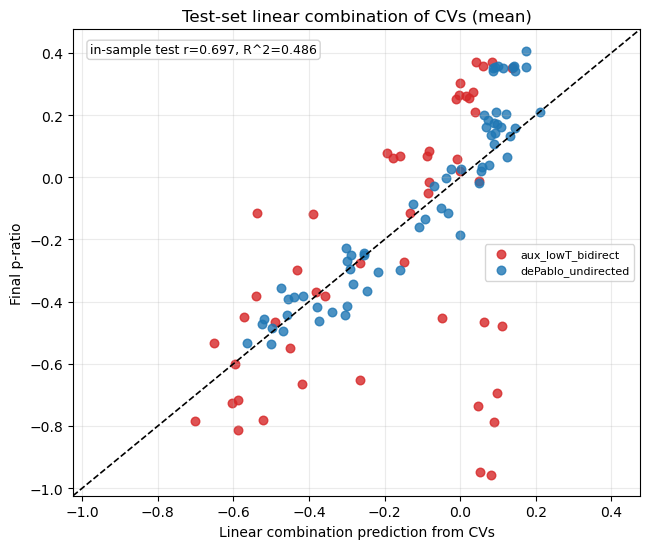

Linear combination weights


,term,weight
0,intercept,-0.169323
1,cv_mean_1,-1.188822
2,cv_mean_2,1.034096
3,cv_mean_3,-1.360321
4,cv_mean_4,-0.013264


saved: ../results/cv_transformer_mixed_sources/cv_transformer_test_linear_combination_vs_pratio.csv
saved: ../results/cv_transformer_mixed_sources/cv_transformer_test_linear_combination_weights.csv


In [ ]:
# Diagnostic: best linear combination of the available CVs for final p-ratio.
# This fits directly on the test set, so treat it as optimistic / descriptive only.
lincomb_cv_cols = [c for c in df_test.columns if c.startswith(f'cv_{cv_summary_type}_')]
X_test = df_test[lincomb_cv_cols].to_numpy(dtype=float)
y_test = df_test['final_p_ratio'].to_numpy(dtype=float)
X_test_aug = np.column_stack([np.ones(len(X_test)), X_test])
coef, *_ = np.linalg.lstsq(X_test_aug, y_test, rcond=None)
y_test_hat = X_test_aug @ coef
lincomb_r2 = fit_r2(y_test_hat, y_test)
lincomb_corr = float(np.corrcoef(y_test_hat, y_test)[0, 1])

coef_df = pd.DataFrame({
    'term': ['intercept'] + lincomb_cv_cols,
    'weight': coef,
})

fig, ax = plt.subplots(figsize=(6.6, 5.6))
for source_name, sub in df_test.assign(pred_lincomb=y_test_hat).groupby('source'):
    color = source_palette.get(source_name, '#6b7280')
    ax.scatter(sub['pred_lincomb'], sub['final_p_ratio'], s=38, alpha=0.80, color=color, label=source_name)
lo = float(min(np.min(y_test_hat), np.min(y_test)))
hi = float(max(np.max(y_test_hat), np.max(y_test)))
pad = 0.05 * (hi - lo + 1e-8)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color='black', lw=1.2, ls='--')
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_xlabel('Linear combination prediction from CVs')
ax.set_ylabel('Final p-ratio')
ax.set_title(f'Test-set linear combination of CVs ({cv_summary_type})')
ax.text(
    0.03,
    0.97,
    f'in-sample test r={lincomb_corr:.3f}, R^2={lincomb_r2:.3f}',
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='0.8'),
)
ax.grid(alpha=0.25)
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

lincomb_pred_df = df_test[['source', 'sim_idx', 'final_p_ratio']].copy()
lincomb_pred_df['pred_lincomb'] = y_test_hat
lincomb_pred_df['lincomb_residual'] = lincomb_pred_df['final_p_ratio'] - lincomb_pred_df['pred_lincomb']
lincomb_csv = run_dir / 'cv_transformer_test_linear_combination_vs_pratio.csv'
coef_csv = run_dir / 'cv_transformer_test_linear_combination_weights.csv'
lincomb_pred_df.to_csv(lincomb_csv, index=False)
coef_df.to_csv(coef_csv, index=False)

print('Linear combination weights')
display(coef_df)
print('saved:', lincomb_csv)
print('saved:', coef_csv)


In [ ]:
# # Test-set Hessian check: selected CV against lambda5.
# hessian_rows = collect_cv_lambda5_points(
#     model=model,
#     sims=test_sims,
#     history=cfg_loaded.history,
#     pos_dim=cfg_loaded.pos_dim,
#     device=device,
#     cv_index=selected_cv_idx,
# )
# hessian_df = pd.DataFrame(hessian_rows)
# hessian_df = hessian_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['cv', 'lambda5']).reset_index(drop=True)

# x = hessian_df['cv'].to_numpy(dtype=float)
# y = hessian_df['lambda5'].to_numpy(dtype=float)
# pearson_r = float(np.corrcoef(x, y)[0, 1])

# fig, ax = plt.subplots(figsize=(6.4, 5.4))
# ax.scatter(x, y, s=14, alpha=0.45)
# ax.set_xlabel(f'Selected collective variable ({selected_cv_col}, {cv_summary_type})')
# ax.set_ylabel('Hessian slow mode $\lambda_5$')
# ax.set_title('Test set: selected CV against $\lambda_5$')
# ax.grid(alpha=0.2)
# ax.text(0.03, 0.97, f'Pearson r = {pearson_r:.3f}\npoints = {len(hessian_df)}', transform=ax.transAxes, va='top', ha='left', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='0.8'))
# plt.tight_layout()
# plt.show()

# hessian_df.head()
